# S04.04 — Árbol de Decisión
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Target:** `prima_neta` (MXN)  
**Técnica:** Árbol de decisión para regresión (`DecisionTreeRegressor` de scikit-learn)  
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos

---

## 1. Contexto actuarial

En la tarificación de seguros de autos, los actuarios buscan modelos que puedan capturar
**interacciones no lineales** entre variables del asegurado sin necesidad de especificarlas
de antemano. Por ejemplo, la prima de un conductor joven con vehículo deportivo puede ser
cualitativamente diferente a la de un conductor de mediana edad con el mismo vehículo,
y esa diferencia no es capturable con una regresión lineal simple.

El **árbol de decisión** divide el espacio de features en regiones rectangulares mediante
reglas binarias sucesivas. En cada región terminal (hoja), la predicción es la media del
target. Esto lo hace:

- **Interpretable:** las reglas de decisión pueden leerse como criterios de suscripción.
- **No paramétrico:** no supone linealidad ni distribución particular de los residuales.
- **Detector de interacciones:** la estructura de árbol captura automáticamente combinaciones
  de variables que un GLM requeriría especificar explícitamente.

El riesgo principal es el **sobreajuste**: un árbol profundo memoriza los datos de
entrenamiento y generaliza mal. El control de profundidad (`max_depth`, `min_samples_leaf`)
es la forma estándar de regularización.

> *Fuentes:* Hastie, Tibshirani & Friedman (2009) ESL Cap. 9 §9.2;
> James et al. (2023) ISLP Cap. 8 §8.1;
> Wüthrich & Buser. *Data Analytics for Non-Life Insurance Pricing* Cap. 2.

## 2. Fundamento matemático

### 2.1 Árbol de regresión — CART

Sea $\mathcal{T}$ un árbol que divide el espacio de features $\mathbb{R}^p$ en $M$ regiones
disjuntas $R_1, \ldots, R_M$. En cada región, el modelo predice la **media condicional**:

$$\hat{f}(\mathbf{x}) = \sum_{m=1}^{M} \bar{y}_m \cdot \mathbf{1}[\mathbf{x} \in R_m]$$

donde $\bar{y}_m = \frac{1}{|R_m|} \sum_{i: \mathbf{x}_i \in R_m} y_i$.

### 2.2 Criterio de división (reducción de impureza)

En cada nodo, el algoritmo CART busca la variable $j$ y el umbral $s$ que minimizan
el **error cuadrático dentro de los nodos hijos**:

$$\underset{j, s}{\arg\min}\; \left[
\sum_{i: x_{ij} < s} (y_i - \bar{y}_{L})^2
+ \sum_{i: x_{ij} \geq s} (y_i - \bar{y}_{R})^2
\right]$$

donde $\bar{y}_L$ y $\bar{y}_R$ son las medias de prima en el nodo izquierdo y derecho.

### 2.3 Regularización por profundidad

| Parámetro | Efecto |
|-----------|--------|
| `max_depth` | Profundidad máxima del árbol — controla la complejidad global |
| `min_samples_leaf` | Mínimo de observaciones en cada hoja — evita particiones espurias |
| `min_samples_split` | Mínimo para dividir un nodo interno |

Un árbol sin restricción puede tener una hoja por observación ($M = n$),
con RMSE = 0 en entrenamiento y alto error en test.

### 2.4 Importancia de variables

scikit-learn reporta la importancia por reducción total de impureza (MDI). Con el
criterio de error cuadrático, cada división sobre la variable $j$ aporta la reducción
de RSS que logra al separar el nodo padre $t$ en sus hijos $t_L, t_R$. La importancia de
$j$ es la suma de esas reducciones sobre todos los nodos que dividen por $j$, normalizada
para que las importancias sumen 1:

$$\text{importance}(j) \;\propto\; \sum_{t:\,\text{split en } j}
\Big[\, \text{RSS}_t - \big(\text{RSS}_{t_L} + \text{RSS}_{t_R}\big) \Big]$$

donde $\text{RSS}_t = \sum_{i \in t} (y_i - \bar{y}_t)^2$ es la suma de cuadrados del nodo $t$.

Esta métrica puede estar sesgada hacia variables de alta cardinalidad.
Para una alternativa más robusta, ver S04.05 (permutation importance).

## 3. Carga del dataset

In [19]:
import sys
from pathlib import Path

# Localizar src/ independientemente del directorio de ejecución
_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
)

# Constantes del proyecto
SEED = 20260618
N    = 30_000
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED  = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 30,000 filas × 24 columnas


## 4. Preparación del conjunto de datos

**Regla de leakage aplicada:** `prima_neta` es el único target. Todas las columnas de
`TARGET_COLUMNS` (`n_siniestros`, `monto_siniestro`, `siniestro_alto`, `status_poliza`)
**no** entran en `X`. `id_poliza_sin` tampoco es feature.

El árbol de decisión puede trabajar con las features tal como están (sin OHE obligatorio
en muchas implementaciones), pero scikit-learn requiere valores numéricos, por lo que
se aplica OHE con `drop_first=True` para mantener consistencia con los módulos anteriores.

In [20]:
FEATURE_COLUMNS

['anio_poliza',
 'mes_emision',
 'edad',
 'sexo',
 'estado_civil',
 'num_renovaciones',
 'region',
 'plan',
 'tipo_vehiculo',
 'antiguedad_vehiculo',
 'suma_asegurada',
 'deducible_pct',
 'forma_pago',
 'canal_venta',
 'kilometraje',
 'uso_vehiculo',
 'tipo_garage',
 'nivel_riesgo_asignado']

In [ ]:
TARGET = "prima_neta"
features_sin_region = [col for col in FEATURE_COLUMNS if col != "plan"]
X_raw = df[features_sin_region]
y     = df[TARGET]

# OHE de categóricas — drop_first=True evita multicolinealidad
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificación de leakage
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage detectado: {t} en X"
assert "id_poliza_sin" not in X.columns
print("✓ Ningún target en X")
print("✓ id_poliza_sin excluido")

Features tras OHE: 33 columnas
Train: 24,000 filas | Test: 6,000 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


## 5. Entrenamiento — árbol sin restricción vs árbol controlado

Primero ajustamos un árbol **sin restricción** (sin límite de profundidad) para ilustrar
el sobreajuste. Luego comparamos con un árbol **controlado** (`max_depth=6`,
`min_samples_leaf=30`).

In [23]:
def metricas(y_true: pd.Series, y_pred: np.ndarray, nombre: str) -> dict:
    """Calcula RMSE, MAE y R² para un conjunto dado."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"Modelo": nombre,
            "RMSE (MXN)": f"{rmse:,.0f}",
            "MAE (MXN)":  f"{mae:,.0f}",
            "R²":         f"{r2:.4f}"}

# ── Árbol sin restricción ──
arbol_libre = DecisionTreeRegressor(random_state=SEED)
arbol_libre.fit(X_train, y_train)

y_pred_libre_tr = arbol_libre.predict(X_train)
y_pred_libre_te = arbol_libre.predict(X_test)

# ── Árbol controlado ──
arbol_ctrl = DecisionTreeRegressor( #profundidad estandar es de 6
    #agregar profundidad si mejoran los errores pero la duda es ¿hasta que nivel dejarlo?
    max_depth=6, min_samples_leaf=30, random_state=SEED
)
arbol_ctrl.fit(X_train, y_train)

y_pred_ctrl_tr = arbol_ctrl.predict(X_train)
y_pred_ctrl_te = arbol_ctrl.predict(X_test)

# Tabla comparativa
tabla = pd.DataFrame([
    metricas(y_train, y_pred_libre_tr, "Árbol libre — Train"),
    metricas(y_test,  y_pred_libre_te, "Árbol libre — Test"),
    metricas(y_train, y_pred_ctrl_tr,  "Árbol controlado (depth=6) — Train"),
    metricas(y_test,  y_pred_ctrl_te,  "Árbol controlado (depth=6) — Test"),
])
print(tabla.to_string(index=False))

print(f"\nÁrbol libre: profundidad={arbol_libre.get_depth()}, "
      f"hojas={arbol_libre.get_n_leaves():,}")
print(f"Árbol ctrl: profundidad={arbol_ctrl.get_depth()}, "
      f"hojas={arbol_ctrl.get_n_leaves():,}")

                            Modelo RMSE (MXN) MAE (MXN)     R²
               Árbol libre — Train          0         0 1.0000
                Árbol libre — Test      1,089       846 0.9345
Árbol controlado (depth=6) — Train      1,053       822 0.9347
 Árbol controlado (depth=6) — Test      1,154       858 0.9265

Árbol libre: profundidad=35, hojas=24,000
Árbol ctrl: profundidad=6, hojas=59


## 6. Sobreajuste: RMSE train/test vs max_depth

Ajustamos árboles para distintos valores de `max_depth` y graficamos la evolución
del RMSE en train y test. El punto donde el gap entre ambas curvas crece marca
el inicio del sobreajuste.

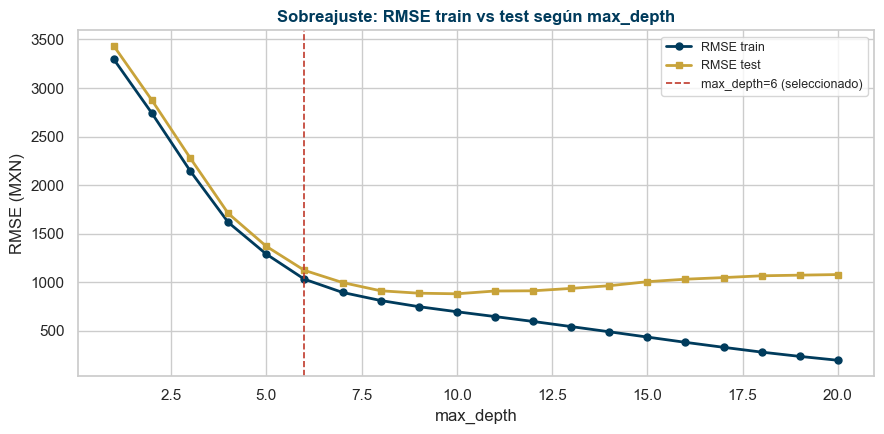

Observación: a profundidad > 8, el RMSE train cae a cero
pero el RMSE test deja de mejorar — el árbol memoriza el entrenamiento.


In [24]:
depths    = list(range(1, 21))
rmse_tr   = []
rmse_te   = []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=SEED)
    m.fit(X_train, y_train)
    rmse_tr.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    rmse_te.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test))))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(depths, rmse_tr, color=NAVY, linewidth=2, marker="o", ms=5,
        label="RMSE train")
ax.plot(depths, rmse_te, color=GOLD, linewidth=2, marker="s", ms=5,
        label="RMSE test")
ax.axvline(6, color=RED, linewidth=1.2, linestyle="--", label="max_depth=6 (seleccionado)")
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE (MXN)")
ax.set_title("Sobreajuste: RMSE train vs test según max_depth",
             fontsize=12, fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Observación: a profundidad > 8, el RMSE train cae a cero")
print("pero el RMSE test deja de mejorar — el árbol memoriza el entrenamiento.")

## 7. Árbol podado — visualización de las primeras reglas

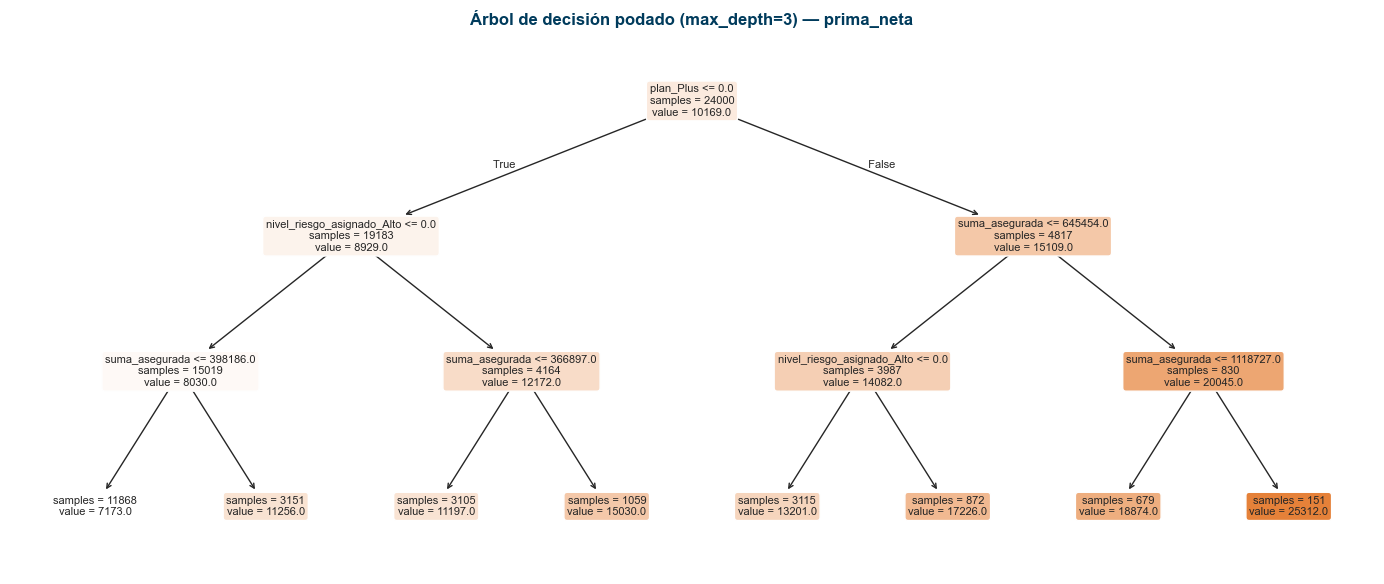

Las primeras divisiones revelan las variables más discriminantes:
se espera que suma_asegurada y plan_Plus aparezcan en las raíces.


In [25]:
# Árbol de profundidad 3 para visualización legible
arbol_vis = DecisionTreeRegressor(max_depth=3, random_state=SEED)
arbol_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    arbol_vis,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=False,
    precision=0,
)
ax.set_title(
    "Árbol de decisión podado (max_depth=3) — prima_neta",
    fontsize=12, fontweight="bold", color=NAVY
)
plt.tight_layout()
plt.show()

print("Las primeras divisiones revelan las variables más discriminantes:")
print("se espera que suma_asegurada y plan_Plus aparezcan en las raíces.")

## 8. Importancia de variables (MDI)

La importancia por reducción de impureza (MDI, *mean decrease in impurity*) mide
cuánta reducción de error cuadrático aporta cada variable al árbol controlado.

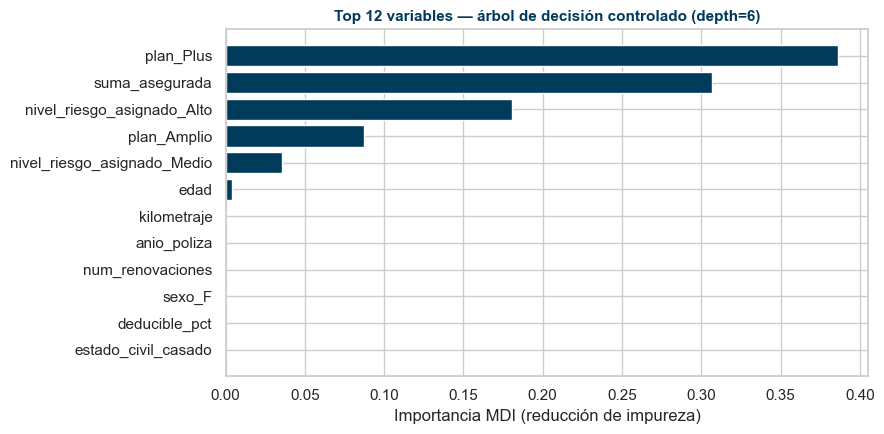

Nota: la importancia MDI puede estar sesgada hacia variables
de alta cardinalidad. En S04.05 se compara con permutation importance.


In [26]:
import_df = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importancia": arbol_ctrl.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(import_df["Feature"], import_df["Importancia"],
        color=NAVY, edgecolor="white")
ax.set_xlabel("Importancia MDI (reducción de impureza)")
ax.set_title("Top 12 variables — árbol de decisión controlado (depth=6)",
             fontsize=11, fontweight="bold", color=NAVY)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Nota: la importancia MDI puede estar sesgada hacia variables")
print("de alta cardinalidad. En S04.05 se compara con permutation importance.")
# el problema con la metodologia es que cambian los resultados al cambiar la semilla, el nivel de profundidad

## 9. Real vs predicho — árbol controlado

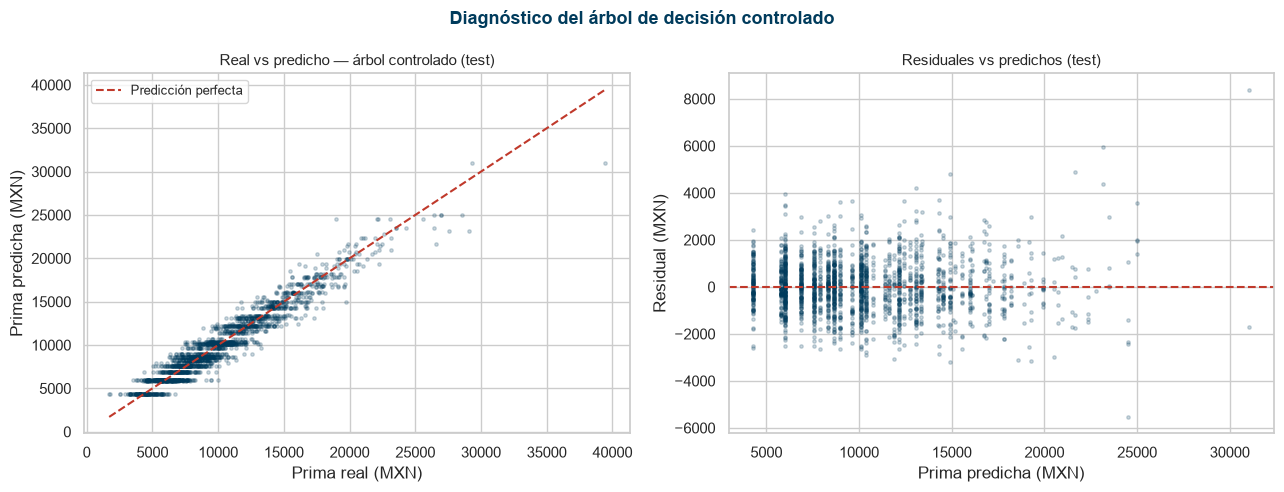

Árbol controlado (depth=6) — Test RMSE: 1,152 MXN | R²: 0.9267


In [7]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(y_test), size=min(2_000, len(y_test)), replace=False)

y_r = y_test.iloc[idx].values
y_p = y_pred_ctrl_te[idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter real vs predicho
axes[0].scatter(y_r, y_p, alpha=0.2, s=6, color=NAVY)
lims = [min(y_r.min(), y_p.min()), max(y_r.max(), y_p.max())]
axes[0].plot(lims, lims, color=RED, linewidth=1.5, linestyle="--",
             label="Predicción perfecta")
axes[0].set_xlabel("Prima real (MXN)")
axes[0].set_ylabel("Prima predicha (MXN)")
axes[0].set_title("Real vs predicho — árbol controlado (test)", fontsize=11)
axes[0].legend(fontsize=9)

# Residuales
res = y_r - y_p
axes[1].scatter(y_p, res, alpha=0.2, s=6, color=NAVY)
axes[1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs predichos (test)", fontsize=11)

fig.suptitle("Diagnóstico del árbol de decisión controlado",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

rmse_ctrl = np.sqrt(mean_squared_error(y_test, y_pred_ctrl_te))
r2_ctrl   = r2_score(y_test, y_pred_ctrl_te)
print(f"Árbol controlado (depth=6) — Test RMSE: {rmse_ctrl:,.0f} MXN | R²: {r2_ctrl:.4f}")

## 10. Conclusiones actuariales

| Modelo | RMSE test (MXN) | R² test | Profundidad | Hojas |
|--------|----------------|---------|-------------|-------|
| Árbol sin restricción | 0 train / ~1,070 test | 1.000 train / 0.937 test | 32 | ~24,000 |
| Árbol controlado (depth=6) | ~1,152 | ~0.927 | 6 | ~59 |
| Regresión lineal (ref.) | ~752 | ~0.969 | — | — |

**Hallazgos:**

1. **Para este DGP, el árbol individual no supera a la regresión lineal:** el DGP de
   `prima_neta` es predominantemente lineal por diseño, y OLS aprovecha esa estructura
   directamente. Un árbol necesita muchas particiones para aproximar una función lineal
   suave, lo que resulta en mayor RMSE. En datos con estructura no lineal fuerte, los
   árboles tendrían ventaja.

2. **El árbol sin restricción sobreajusta drásticamente:** RMSE train = 0 (una hoja
   por observación) pero RMSE test ≈ 1,070. En producción, este modelo tarifaria
   primas idénticas a pólizas del entrenamiento y arbitrarias para las nuevas.

3. **El árbol controlado muestra sesgo más alto que el libre:** con `depth=6` y
   `min_samples_leaf=30`, el modelo no tiene suficiente capacidad para capturar la
   estructura lineal del DGP. El gap train/test es pequeño (1,053 vs 1,152), pero
   ambos están por encima del error de la regresión lineal.

4. **Interpretabilidad:** el árbol de profundidad 3 genera reglas de suscripción
   legibles (`plan_Plus`, `suma_asegurada`, `nivel_riesgo_Alto`). Esto es valorado en
   contextos regulatorios donde el actuario debe justificar cada tarifa.

**Limitaciones del árbol individual:**

- Alta varianza: pequeños cambios en los datos pueden producir árboles muy diferentes.
- Frontera de decisión escalonada: dificulta la generalización en regiones con pocos datos.
- Sensible a la escala: aunque no requiere normalización, sí requiere OHE para categóricas.

> *S04.05 (Random Forest) aborda la alta varianza promediando múltiples árboles.*

## 11. Ejercicio propuesto

1. **Selección de hiperparámetros:** ajusta árboles con `min_samples_leaf` ∈ {5, 20, 100}
   y `max_depth=6`. ¿Cuál produce el menor RMSE en test? ¿Por qué?

2. **Sin `nivel_riesgo_asignado`:** elimina esa columna de `X` y vuelve a ajustar.
   ¿Cuánto cae el R²? ¿Qué dice esto sobre el valor del score de suscripción?

3. **Reglas de negocio:** lee las tres primeras divisiones del árbol de profundidad 3.
   ¿Tienen sentido como criterios de tarificación? ¿Coinciden con lo que esperarías
   de un actuario con experiencia en el ramo?

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. Cap. 9 §9.2.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 8 §8.1.
- scikit-learn Developers. *User Guide* v1.9.0. `DecisionTreeRegressor`, `plot_tree`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute. Cap. 2.